In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

Device utilisé: cpu


In [ ]:
# EXERCICE 1.1 - ENCODAGE
class DenseEncoder(nn.Module):
    """Encodeur basé uniquement sur des couches denses"""

    def __init__(self, input_dim=784, hidden_dims=[512, 256], latent_dim=20):
        super(DenseEncoder, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Construction des couches cachées
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        self.hidden_layers = nn.Sequential(*layers)

        # Couches finales pour μ et log(σ²)
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_log_var = nn.Linear(prev_dim, latent_dim)

        # Calcul du nombre de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        # Aplatir l'entrée si nécessaire
        if len(x.shape) > 2:
            x = x.view(x.size(0), -1)

        # Passage dans les couches cachées
        h = self.hidden_layers(x)

        # Calcul de μ et log(σ²)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)

        return mu, log_var

class ConvEncoder(nn.Module):
    """Encodeur basé sur des couches convolutionnelles"""

    def __init__(self, latent_dim=20, input_channels=1):
        super(ConvEncoder, self).__init__()

        self.latent_dim = latent_dim

        # Couches convolutionnelles
        self.conv_layers = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(input_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            # 14x14 -> 7x7
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            # 7x7 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
        )

        # Taille après convolutions : 128 * 4 * 4 = 2048
        self.flatten_size = 128 * 4 * 4

        # Couches denses finales
        self.fc_hidden = nn.Sequential(
            nn.Linear(self.flatten_size, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256)
        )

        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

        # Calcul du nombre de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        # Passage dans les couches convolutionnelles
        h = self.conv_layers(x)

        # Aplatissement
        h = h.view(h.size(0), -1)

        # Couches denses
        h = self.fc_hidden(h)

        # Calcul de μ et log(σ²)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)

        return mu, log_var

In [ ]:
# EXERCICE 1.2 - DÉCODAGE
class DenseDecoder(nn.Module):
    """Décodeur basé uniquement sur des couches denses"""

    def __init__(self, latent_dim=20, hidden_dims=[256, 512], output_dim=784):
        super(DenseDecoder, self).__init__()

        self.latent_dim = latent_dim
        self.output_dim = output_dim

        # Construction des couches cachées
        layers = []
        prev_dim = latent_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        self.hidden_layers = nn.Sequential(*layers)

        # Couche finale de reconstruction
        self.fc_output = nn.Linear(prev_dim, output_dim)

        # Calcul du nombre de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, z):
        # Passage dans les couches cachées
        h = self.hidden_layers(z)

        # Reconstruction
        x_recon = torch.sigmoid(self.fc_output(h))  # Sigmoid pour [0,1]

        return x_recon

class ConvDecoder(nn.Module):
    """Décodeur basé sur des couches convolutionnelles transposes"""

    def __init__(self, latent_dim=20, output_channels=1):
        super(ConvDecoder, self).__init__()

        self.latent_dim = latent_dim

        # Couche dense initiale pour passer à la forme convolutionnelle
        self.fc_initial = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128 * 4 * 4),  # 128 canaux, 4x4
            nn.ReLU()
        )

        # Couches de déconvolution (transposed convolution)
        self.deconv_layers = nn.Sequential(
            # 4x4 -> 7x7
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(32, output_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()  # Sigmoid pour [0,1]
        )

        # Couche finale pour ajuster à 28x28 si nécessaire
        self.final_crop = nn.AdaptiveAvgPool2d((28, 28))

        # Calcul du nombre de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, z):
        # Passage par la couche dense initiale
        h = self.fc_initial(z)

        # Reshape pour les convolutions : (batch_size, 128, 4, 4)
        h = h.view(h.size(0), 128, 4, 4)

        # Déconvolutions
        x_recon = self.deconv_layers(h)

        # Ajustement final à 28x28
        x_recon = self.final_crop(x_recon)

        return x_recon

In [ ]:
# EXERCICE 1.3 - MODULE VAE COMPLET
class VAE(nn.Module):
    """Module VAE complet avec encodeur, décodeur et reparameterization trick"""

    def __init__(self, encoder, decoder, latent_dim=20):
        super(VAE, self).__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.latent_dim = latent_dim

        # Calcul du nombre total de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def reparameterize(self, mu, log_var):
        """Reparameterization trick: z = μ + σ * ε"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        """Forward pass complet du VAE"""
        # Encodage
        mu, log_var = self.encoder(x)

        # Reparameterization
        z = self.reparameterize(mu, log_var)

        # Décodage
        x_recon = self.decoder(z)

        return x_recon, mu, log_var, z

    def generate(self, num_samples=1):
        """Génération de nouvelles données"""
        with torch.no_grad():
            # Échantillonnage dans l'espace latent
            z = torch.randn(num_samples, self.latent_dim)

            # Décodage
            generated = self.decoder(z)

            return generated

    def encode(self, x):
        """Encodage seulement"""
        with torch.no_grad():
            mu, log_var = self.encoder(x)
            z = self.reparameterize(mu, log_var)
            return z, mu, log_var

    def decode(self, z):
        """Décodage seulement"""
        with torch.no_grad():
            return self.decoder(z)

# Fonction de perte VAE
def vae_loss_function(x_recon, x, mu, log_var, beta=1.0):
    """Fonction de perte VAE : reconstruction + régularisation KL"""

    # Terme de reconstruction (Binary Cross Entropy)
    if len(x.shape) > 2:
        x = x.view(x.size(0), -1)
    if len(x_recon.shape) > 2:
        x_recon = x_recon.view(x_recon.size(0), -1)

    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')

    # Terme de régularisation KL
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Perte totale
    total_loss = recon_loss + beta * kl_div

    return total_loss, recon_loss, kl_div

    def forward(self, z):
        # Passage par la couche dense initiale
        h = self.fc_initial(z)

        # Reshape pour les convolutions : (batch_size, 128, 4, 4)
        h = h.view(h.size(0), 128, 4, 4)

        # Déconvolutions
        x_recon = self.deconv_layers(h)

        # Ajustement final à 28x28
        x_recon = self.final_crop(x_recon)

        return x_recon

# Test des encodeurs et décodeurs
def test_encoders_decoders():
    print("=== TEST EXERCICE 1.1 - ENCODEURS ===")

    # Données de test (normalisées entre 0 et 1)
    batch_size = 32
    test_input = torch.rand(batch_size, 1, 28, 28)  # Uniform[0,1] au lieu de Normal

    # Test encodeur dense
    dense_encoder = DenseEncoder(input_dim=784, hidden_dims=[512, 256], latent_dim=20)
    mu_dense, log_var_dense = dense_encoder(test_input)

    print(f"\n📊 ENCODEUR DENSE:")
    print(f"   - Architecture: 784 → 512 → 256 → 20")
    print(f"   - Nombre de paramètres: {dense_encoder.num_params:,}")
    print(f"   - Forme μ: {mu_dense.shape}")
    print(f"   - Forme log(σ²): {log_var_dense.shape}")

    # Test encodeur convolutionnel
    conv_encoder = ConvEncoder(latent_dim=20)
    mu_conv, log_var_conv = conv_encoder(test_input)

    print(f"\n🔍 ENCODEUR CONVOLUTIONNEL:")
    print(f"   - Architecture: Conv[32,64,128] → FC[256] → 20")
    print(f"   - Nombre de paramètres: {conv_encoder.num_params:,}")
    print(f"   - Forme μ: {mu_conv.shape}")
    print(f"   - Forme log(σ²): {log_var_conv.shape}")

    return dense_encoder, conv_encoder

def test_decoders():
    print("\n=== TEST EXERCICE 1.2 - DÉCODEURS ===\n")

    # Données de test (espace latent)
    batch_size = 32
    latent_dim = 20
    test_latent = torch.randn(batch_size, latent_dim)

    # Test décodeur dense
    dense_decoder = DenseDecoder(latent_dim=20, hidden_dims=[256, 512], output_dim=784)
    x_recon_dense = dense_decoder(test_latent)

    print(f"📊 DÉCODEUR DENSE:")
    print(f"   - Architecture: 20 → 256 → 512 → 784")
    print(f"   - Nombre de paramètres: {dense_decoder.num_params:,}")
    print(f"   - Forme reconstruction: {x_recon_dense.shape}")
    print(f"   - Valeurs dans [0,1]: {x_recon_dense.min():.3f} - {x_recon_dense.max():.3f}")

    # Test décodeur convolutionnel
    conv_decoder = ConvDecoder(latent_dim=20)
    x_recon_conv = conv_decoder(test_latent)

    print(f"\n🔍 DÉCODEUR CONVOLUTIONNEL:")
    print(f"   - Architecture: FC[256, 2048] → DeConv[64,32,1]")
    print(f"   - Nombre de paramètres: {conv_decoder.num_params:,}")
    print(f"   - Forme reconstruction: {x_recon_conv.shape}")
    print(f"   - Valeurs dans [0,1]: {x_recon_conv.min():.3f} - {x_recon_conv.max():.3f}")

    return dense_decoder, conv_decoder

def test_vae_complete():
    print("\n=== TEST EXERCICE 1.3 - VAE COMPLET ===\n")

    # Création des VAE complets
    dense_encoder = DenseEncoder(input_dim=784, hidden_dims=[512, 256], latent_dim=20)
    dense_decoder = DenseDecoder(latent_dim=20, hidden_dims=[256, 512], output_dim=784)
    dense_vae = VAE(dense_encoder, dense_decoder, latent_dim=20)

    conv_encoder = ConvEncoder(latent_dim=20)
    conv_decoder = ConvDecoder(latent_dim=20)
    conv_vae = VAE(conv_encoder, conv_decoder, latent_dim=20)

    # Données de test (normalisées entre 0 et 1)
    batch_size = 4
    test_input = torch.rand(batch_size, 1, 28, 28)  # Uniform[0,1] au lieu de Normal

    print(f"🤖 VAE DENSE:")
    print(f"   - Paramètres totaux: {dense_vae.num_params:,}")

    # Test forward pass
    x_recon_dense, mu_dense, log_var_dense, z_dense = dense_vae(test_input)
    loss_dense, recon_dense, kl_dense = vae_loss_function(
        x_recon_dense.view(batch_size, 1, 28, 28), test_input, mu_dense, log_var_dense
    )

    print(f"   - Reconstruction: {x_recon_dense.shape}")
    print(f"   - Espace latent: {z_dense.shape}")
    print(f"   - Perte totale: {loss_dense.item():.2f}")
    print(f"   - Perte reconstruction: {recon_dense.item():.2f}")
    print(f"   - Divergence KL: {kl_dense.item():.2f}")

    # Test génération
    generated_dense = dense_vae.generate(num_samples=2)
    print(f"   - Génération: {generated_dense.shape}")

    print(f"\n🔍 VAE CONVOLUTIONNEL:")
    print(f"   - Paramètres totaux: {conv_vae.num_params:,}")

    # Test forward pass
    x_recon_conv, mu_conv, log_var_conv, z_conv = conv_vae(test_input)
    loss_conv, recon_conv, kl_conv = vae_loss_function(
        x_recon_conv, test_input, mu_conv, log_var_conv
    )

    print(f"   - Reconstruction: {x_recon_conv.shape}")
    print(f"   - Espace latent: {z_conv.shape}")
    print(f"   - Perte totale: {loss_conv.item():.2f}")
    print(f"   - Perte reconstruction: {recon_conv.item():.2f}")
    print(f"   - Divergence KL: {kl_conv.item():.2f}")

    # Test génération
    generated_conv = conv_vae.generate(num_samples=2)
    print(f"   - Génération: {generated_conv.shape}")

    return dense_vae, conv_vae

def test_reconstruction_cycle():
    print("\n=== TEST CYCLE COMPLET ENCODAGE-DÉCODAGE (version détaillée) ===\n")

    # Données de test MNIST-like (normalisées entre 0 et 1)
    batch_size = 4
    test_input = torch.rand(batch_size, 1, 28, 28)  # Uniform[0,1] au lieu de Normal

    # Architecture dense
    dense_encoder = DenseEncoder(input_dim=784, hidden_dims=[512, 256], latent_dim=20)
    dense_decoder = DenseDecoder(latent_dim=20, hidden_dims=[256, 512], output_dim=784)

    # Encodage
    mu, log_var = dense_encoder(test_input)

    # Reparameterization trick
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    z = mu + eps * std

    # Décodage
    x_recon = dense_decoder(z)
    x_recon = x_recon.view(batch_size, 1, 28, 28)

    print(f"🔄 CYCLE DENSE:")
    print(f"   - Entrée: {test_input.shape}")
    print(f"   - Espace latent: {z.shape}")
    print(f"   - Reconstruction: {x_recon.shape}")

    # Architecture convolutionnelle
    conv_encoder = ConvEncoder(latent_dim=20)
    conv_decoder = ConvDecoder(latent_dim=20)

    mu_conv, log_var_conv = conv_encoder(test_input)
    std_conv = torch.exp(0.5 * log_var_conv)
    eps_conv = torch.randn_like(std_conv)
    z_conv = mu_conv + eps_conv * std_conv
    x_recon_conv = conv_decoder(z_conv)

    print(f"\n🔄 CYCLE CONVOLUTIONNEL:")
    print(f"   - Entrée: {test_input.shape}")
    print(f"   - Espace latent: {z_conv.shape}")
    print(f"   - Reconstruction: {x_recon_conv.shape}")

if __name__ == "__main__":
    # Test de l'exercice 1.1
    dense_enc, conv_enc = test_encoders_decoders()

    # Test de l'exercice 1.2
    dense_dec, conv_dec = test_decoders()

    # Test de l'exercice 1.3
    dense_vae, conv_vae = test_vae_complete()

    # Test du cycle complet (version détaillée)
    test_reconstruction_cycle()

=== TEST EXERCICE 1.1 - ENCODEURS ===

📊 ENCODEUR DENSE:
   - Architecture: 784 → 512 → 256 → 20
   - Nombre de paramètres: 545,064
   - Forme μ: torch.Size([32, 20])
   - Forme log(σ²): torch.Size([32, 20])

🔍 ENCODEUR CONVOLUTIONNEL:
   - Architecture: Conv[32,64,128] → FC[256] → 20
   - Nombre de paramètres: 643,016
   - Forme μ: torch.Size([32, 20])
   - Forme log(σ²): torch.Size([32, 20])

=== TEST EXERCICE 1.2 - DÉCODEURS ===

📊 DÉCODEUR DENSE:
   - Architecture: 20 → 256 → 512 → 784
   - Nombre de paramètres: 540,688
   - Forme reconstruction: torch.Size([32, 784])
   - Valeurs dans [0,1]: 0.079 - 0.933

🔍 DÉCODEUR CONVOLUTIONNEL:
   - Architecture: FC[256, 2048] → DeConv[64,32,1]
   - Nombre de paramètres: 639,521
   - Forme reconstruction: torch.Size([32, 1, 28, 28])
   - Valeurs dans [0,1]: 0.008 - 0.985

=== TEST EXERCICE 1.3 - VAE COMPLET ===

🤖 VAE DENSE:
   - Paramètres totaux: 1,085,752
   - Reconstruction: torch.Size([4, 784])
   - Espace latent: torch.Size([4, 20])
   

Passge à l'ex 2


=== EXERCICE 2.1 - ENTRAÎNEMENT VAE SUR MNIST ===

📥 Chargement des données MNIST...


100%|██████████| 9.91M/9.91M [00:00<00:00, 37.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 994kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.25MB/s]


   - Données d'entraînement: 60000 images
   - Données de test: 10000 images
   - Taille des batches: 128

🏗️  Création des modèles VAE...
📊 VAE Dense - Paramètres: 1,085,752
🔍 VAE Convolutionnel - Paramètres: 1,282,537


🚀 Entraînement du VAE Dense
   - Epochs: 10
   - Learning rate: 0.001
   - Beta (KL weight): 1.0
   - Nombre de batches: 469


Epoch 1/10: 100%|██████████| 469/469 [00:14<00:00, 33.21it/s, Loss=11100.79, Recon=8997.50, KL=2103.29]


Epoch 1: Loss=22625.46, Recon=20342.58, KL=2282.88


...

Epoch 9: Loss=13139.67, Recon=10154.64, KL=2985.03


Epoch 10/10: 100%|██████████| 469/469 [01:09<00:00,  6.72it/s, Loss=9779.41, Recon=7576.35, KL=2203.06]

Epoch 10: Loss=13094.23, Recon=10113.58, KL=2980.65
✅ Entraînement du VAE Convolutionnel terminé!

🧪 ÉVALUATION SUR LES DONNÉES DE TEST



📊 Test VAE Dense:
   - Perte totale: 12921.57
   - Perte reconstruction: 9874.27
   - Divergence KL: 3047.30
📊 Test VAE Convolutionnel:
   - Perte totale: 12798.73
   - Perte reconstruction: 9889.29
   - Divergence KL: 2909.44

📈 Génération des courbes d'entraînement...


FileNotFoundError: [Errno 2] No such file or directory: '/home/user/training_curves.png'

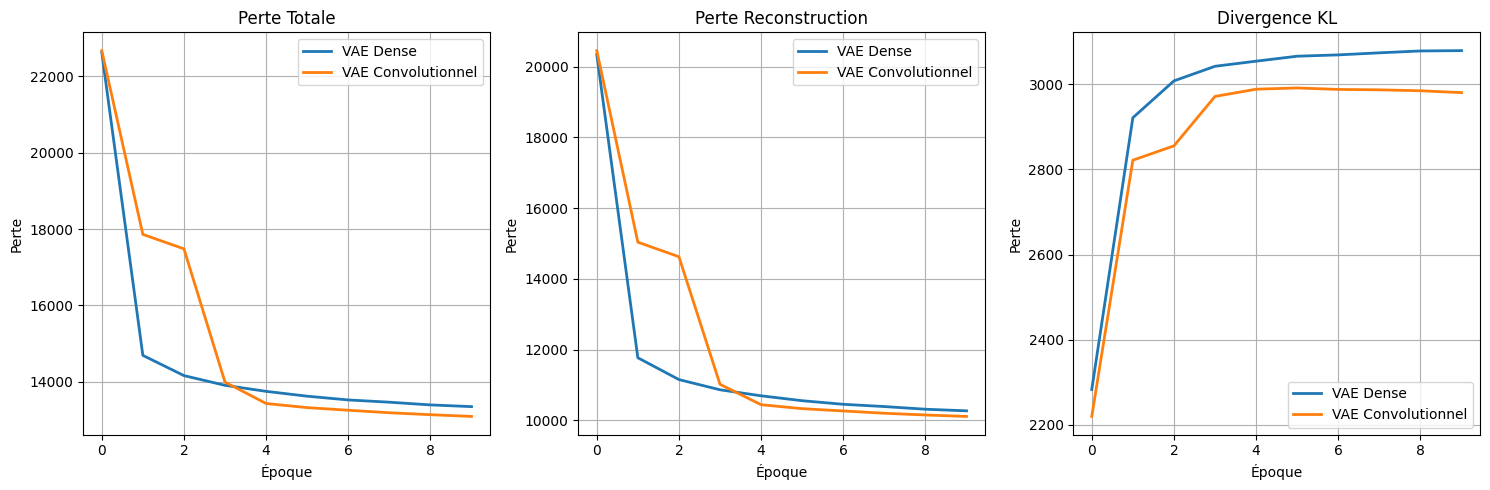

In [ ]:
def load_mnist_data(batch_size=64, train=True):
    """Chargement des données MNIST"""

    # Transformation : conversion en tenseur et normalisation [0,1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        # Pas de normalisation supplémentaire car MNIST est déjà en [0,1] après ToTensor()
    ])

    # Chargement du dataset
    dataset = torchvision.datasets.MNIST(
        root='./data',
        train=train,
        download=True,
        transform=transform
    )

    # DataLoader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=train,
        num_workers=2
    )

    return dataloader, dataset

def create_vae_models(latent_dim=20):
    """Création des modèles VAE dense et convolutionnel"""

    # VAE Dense
    dense_encoder = DenseEncoder(input_dim=784, hidden_dims=[512, 256], latent_dim=latent_dim)
    dense_decoder = DenseDecoder(latent_dim=latent_dim, hidden_dims=[256, 512], output_dim=784)
    dense_vae = VAE(dense_encoder, dense_decoder, latent_dim=latent_dim).to(device)

    # VAE Convolutionnel
    conv_encoder = ConvEncoder(latent_dim=latent_dim)
    conv_decoder = ConvDecoder(latent_dim=latent_dim)
    conv_vae = VAE(conv_encoder, conv_decoder, latent_dim=latent_dim).to(device)

    print(f"📊 VAE Dense - Paramètres: {dense_vae.num_params:,}")
    print(f"🔍 VAE Convolutionnel - Paramètres: {conv_vae.num_params:,}")

    return dense_vae, conv_vae

def train_vae(model, train_loader, num_epochs=10, learning_rate=1e-3, beta=1.0, model_name="VAE"):
    """Entraînement d'un modèle VAE"""

    # Optimiseur
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Historique des pertes
    train_losses = []
    recon_losses = []
    kl_losses = []

    print(f"\n🚀 Entraînement du {model_name}")
    print(f"   - Epochs: {num_epochs}")
    print(f"   - Learning rate: {learning_rate}")
    print(f"   - Beta (KL weight): {beta}")
    print(f"   - Nombre de batches: {len(train_loader)}")

    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0
        epoch_recon = 0
        epoch_kl = 0

        # Barre de progression
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(device)

            # Forward pass
            x_recon, mu, log_var, z = model(data)

            # Calcul de la perte
            loss, recon_loss, kl_div = vae_loss_function(x_recon, data, mu, log_var, beta)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulation des pertes
            epoch_loss += loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_div.item()

            # Mise à jour de la barre de progression
            pbar.set_postfix({
                'Loss': f'{loss.item():.2f}',
                'Recon': f'{recon_loss.item():.2f}',
                'KL': f'{kl_div.item():.2f}'
            })

        # Moyennes de l'époque
        avg_loss = epoch_loss / len(train_loader)
        avg_recon = epoch_recon / len(train_loader)
        avg_kl = epoch_kl / len(train_loader)

        train_losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.2f}, Recon={avg_recon:.2f}, KL={avg_kl:.2f}")

    print(f"✅ Entraînement du {model_name} terminé!")

    return {
        'train_losses': train_losses,
        'recon_losses': recon_losses,
        'kl_losses': kl_losses
    }

def plot_training_curves(histories, model_names):
    """Visualisation des courbes d'entraînement"""

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    metrics = ['train_losses', 'recon_losses', 'kl_losses']
    titles = ['Perte Totale', 'Perte Reconstruction', 'Divergence KL']

    for i, (metric, title) in enumerate(zip(metrics, titles)):
        for history, name in zip(histories, model_names):
            axes[i].plot(history[metric], label=name, linewidth=2)

        axes[i].set_title(title)
        axes[i].set_xlabel('Époque')
        axes[i].set_ylabel('Perte')
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.savefig('/home/user/training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("📈 Courbes d'entraînement sauvegardées: training_curves.png")

def test_model(model, test_loader, model_name="VAE"):
    """Test d'un modèle entraîné"""

    model.eval()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            x_recon, mu, log_var, z = model(data)
            loss, recon_loss, kl_div = vae_loss_function(x_recon, data, mu, log_var)

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_div.item()

    avg_loss = total_loss / len(test_loader)
    avg_recon = total_recon / len(test_loader)
    avg_kl = total_kl / len(test_loader)

    print(f"📊 Test {model_name}:")
    print(f"   - Perte totale: {avg_loss:.2f}")
    print(f"   - Perte reconstruction: {avg_recon:.2f}")
    print(f"   - Divergence KL: {avg_kl:.2f}")

    return avg_loss, avg_recon, avg_kl

def main_training():
    """Fonction principale d'entraînement"""

    print("=== EXERCICE 2.1 - ENTRAÎNEMENT VAE SUR MNIST ===\n")

    # Paramètres d'entraînement
    batch_size = 128
    num_epochs = 10
    learning_rate = 1e-3
    latent_dim = 20
    beta = 1.0

    # Chargement des données
    print("📥 Chargement des données MNIST...")
    train_loader, train_dataset = load_mnist_data(batch_size=batch_size, train=True)
    test_loader, test_dataset = load_mnist_data(batch_size=batch_size, train=False)

    print(f"   - Données d'entraînement: {len(train_dataset)} images")
    print(f"   - Données de test: {len(test_dataset)} images")
    print(f"   - Taille des batches: {batch_size}")

    # Création des modèles
    print("\n🏗️  Création des modèles VAE...")
    dense_vae, conv_vae = create_vae_models(latent_dim=latent_dim)

    # Entraînement du VAE Dense
    print("\n" + "="*50)
    dense_history = train_vae(
        dense_vae, train_loader,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        beta=beta,
        model_name="VAE Dense"
    )

    # Entraînement du VAE Convolutionnel
    print("\n" + "="*50)
    conv_history = train_vae(
        conv_vae, train_loader,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        beta=beta,
        model_name="VAE Convolutionnel"
    )

    # Test des modèles
    print("\n" + "="*50)
    print("🧪 ÉVALUATION SUR LES DONNÉES DE TEST\n")

    dense_test_results = test_model(dense_vae, test_loader, "VAE Dense")
    conv_test_results = test_model(conv_vae, test_loader, "VAE Convolutionnel")

    # Visualisation des courbes d'entraînement
    print("\n📈 Génération des courbes d'entraînement...")
    plot_training_curves([dense_history, conv_history], ["VAE Dense", "VAE Convolutionnel"])

    # Sauvegarde des modèles
    print("\n💾 Sauvegarde des modèles...")
    torch.save(dense_vae.state_dict(), '/home/user/dense_vae_model.pth')
    torch.save(conv_vae.state_dict(), '/home/user/conv_vae_model.pth')
    print("   - dense_vae_model.pth")
    print("   - conv_vae_model.pth")

    return dense_vae, conv_vae, dense_history, conv_history

if __name__ == "__main__":
    # Lancement de l'entraînement
    dense_vae, conv_vae, dense_hist, conv_hist = main_training()

In [ ]:
#Exercices 3 - Expérimentations VAE
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os


def quick_experiment_demo():
    """Démonstration rapide des 3 exercices"""

    print("=== EXPÉRIMENTATIONS VAE - VERSION RAPIDE ===\\n")

    # Paramètres pour démo rapide
    batch_size = 256
    num_epochs = 2
    learning_rate = 1e-3

    # Données réduites
    transform = transforms.Compose([transforms.ToTensor()])
    full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

    subset_size = 3000
    indices = torch.randperm(len(full_dataset))[:subset_size]
    train_dataset = torch.utils.data.Subset(full_dataset, indices)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Test data
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)
    test_images, test_labels = next(iter(test_loader))
    test_images = test_images.to(device)

    print(f"📥 Données: {subset_size} échantillons d'entraînement")


=== EXERCICE 3.1 - GÉNÉRATION ET VISUALISATION ===
📥 Données: 3000 échantillons d'entraînement
🚀 Entraînement Dense VAE...


Epoch 1: 100%|██████████| 12/12 [00:00<00:00, 22.71it/s]


   Epoch 1: Loss = 138607


Epoch 2: 100%|██████████| 12/12 [00:00<00:00, 23.70it/s]


   Epoch 2: Loss = 130507


...

   Epoch 8: Loss = 45110


Epoch 9: 100%|██████████| 12/12 [00:03<00:00,  3.13it/s]


   Epoch 9: Loss = 43179


Epoch 10: 100%|██████████| 12/12 [00:03<00:00,  3.47it/s]


   Epoch 10: Loss = 41109
✅ Conv VAE entraîné

📊 Génération des visualisations...


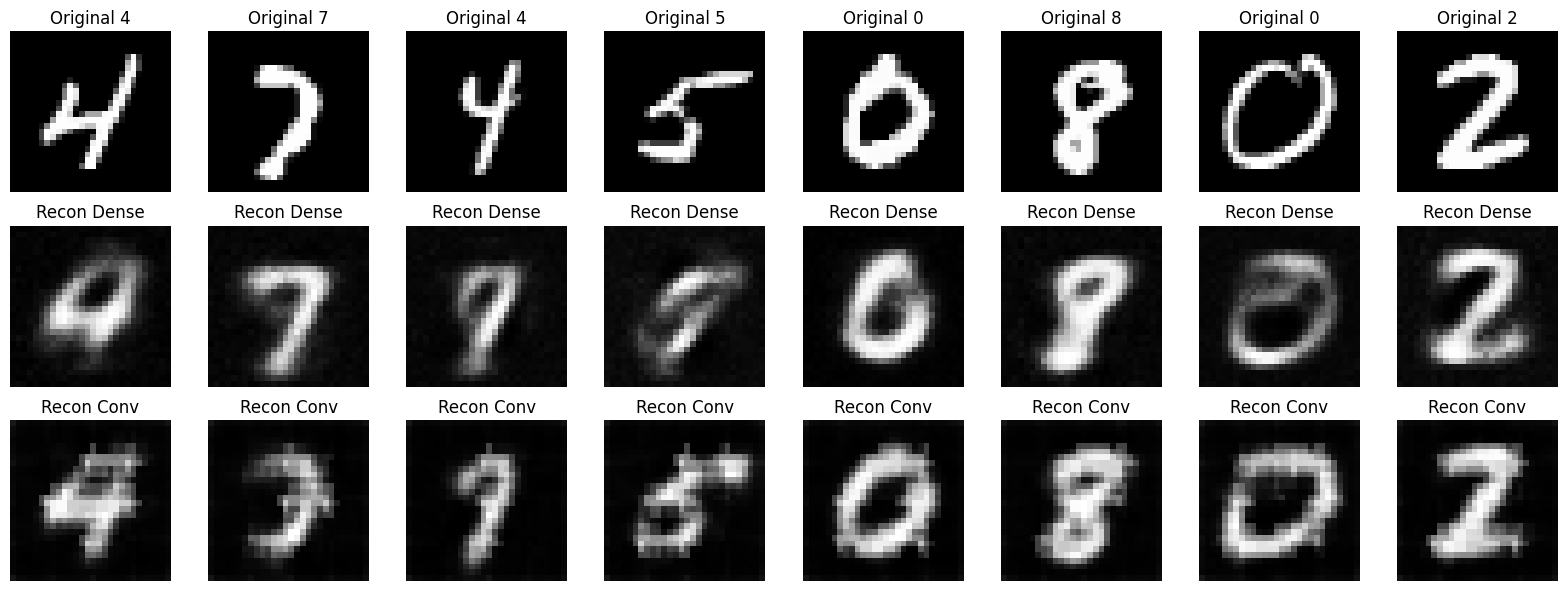

💾 Exercice 3.1 sauvegardé: exercise_3_1_demo.png


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# EXERCICE 3.1 - GÉNÉRATION ET VISUALISATION
print("\n=== EXERCICE 3.1 - GÉNÉRATION ET VISUALISATION ===")

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define parameters for this quick experiment
num_epochs = 10
learning_rate = 1e-3
latent_dim = 10

# EXERCICE 1.1 - ENCODAGE
class DenseEncoder(nn.Module):
    """Encodeur basé uniquement sur des couches denses"""

    def __init__(self, input_dim=784, hidden_dims=[512, 256], latent_dim=20):
        super(DenseEncoder, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Construction des couches cachées
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        self.hidden_layers = nn.Sequential(*layers)

        # Couches finales pour μ et log(σ²)
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_log_var = nn.Linear(prev_dim, latent_dim)

        # Calcul du nombre de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        # Aplatir l'entrée si nécessaire
        if len(x.shape) > 2:
            x = x.view(x.size(0), -1)

        # Passage dans les couches cachées
        h = self.hidden_layers(x)

        # Calcul de μ et log(σ²)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)

        return mu, log_var

class ConvEncoder(nn.Module):
    """Encodeur basé sur des couches convolutionnelles"""

    def __init__(self, latent_dim=20, input_channels=1):
        super(ConvEncoder, self).__init__()

        self.latent_dim = latent_dim

        # Couches convolutionnelles
        self.conv_layers = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(input_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            # 14x14 -> 7x7
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            # 7x7 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
        )

        # Taille après convolutions : 128 * 4 * 4 = 2048
        self.flatten_size = 128 * 4 * 4

        # Couches denses finales
        self.fc_hidden = nn.Sequential(
            nn.Linear(self.flatten_size, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256)
        )

        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

        # Calcul du nombre de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, x):
        # Passage dans les couches convolutionnelles
        h = self.conv_layers(x)

        # Aplatissement
        h = h.view(h.size(0), -1)

        # Couches denses
        h = self.fc_hidden(h)

        # Calcul de μ et log(σ²)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)

        return mu, log_var

# EXERCICE 1.2 - DÉCODAGE
class DenseDecoder(nn.Module):
    """Décodeur basé uniquement sur des couches denses"""

    def __init__(self, latent_dim=20, hidden_dims=[256, 512], output_dim=784):
        super(DenseDecoder, self).__init__()

        self.latent_dim = latent_dim
        self.output_dim = output_dim

        # Construction des couches cachées
        layers = []
        prev_dim = latent_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        self.hidden_layers = nn.Sequential(*layers)

        # Couche finale de reconstruction
        self.fc_output = nn.Linear(prev_dim, output_dim)

        # Calcul du nombre de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, z):
        # Passage dans les couches cachées
        h = self.hidden_layers(z)

        # Reconstruction
        x_recon = torch.sigmoid(self.fc_output(h))  # Sigmoid pour [0,1]

        return x_recon

class ConvDecoder(nn.Module):
    """Décodeur basé sur des couches convolutionnelles transposes"""

    def __init__(self, latent_dim=20, output_channels=1):
        super(ConvDecoder, self).__init__()

        self.latent_dim = latent_dim

        # Couche dense initiale pour passer à la forme convolutionnelle
        self.fc_initial = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128 * 4 * 4),  # 128 canaux, 4x4
            nn.ReLU()
        )

        # Couches de déconvolution (transposed convolution)
        self.deconv_layers = nn.Sequential(
            # 4x4 -> 7x7
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(32, output_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()  # Sigmoid pour [0,1]
        )

        # Couche finale pour ajuster à 28x28 si nécessaire
        self.final_crop = nn.AdaptiveAvgPool2d((28, 28))

        # Calcul du nombre de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def forward(self, z):
        # Passage par la couche dense initiale
        h = self.fc_initial(z)

        # Reshape pour les convolutions : (batch_size, 128, 4, 4)
        h = h.view(h.size(0), 128, 4, 4)

        # Déconvolutions
        x_recon = self.deconv_layers(h)

        # Ajustement final à 28x28
        x_recon = self.final_crop(x_recon)

        return x_recon

# EXERCICE 1.3 - MODULE VAE COMPLET
class VAE(nn.Module):
    """Module VAE complet avec encodeur, décodeur et reparameterization trick"""

    def __init__(self, encoder, decoder, latent_dim=20):
        super(VAE, self).__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.latent_dim = latent_dim

        # Calcul du nombre total de paramètres
        self.num_params = sum(p.numel() for p in self.parameters())

    def reparameterize(self, mu, log_var):
        """Reparameterization trick: z = μ + σ * ε"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        """Forward pass complet du VAE"""
        # Encodage
        mu, log_var = self.encoder(x)

        # Reparameterization
        z = self.reparameterize(mu, log_var)

        # Décodage
        x_recon = self.decoder(z)

        return x_recon, mu, log_var, z

    def generate(self, num_samples=1):
        """Génération de nouvelles données"""
        with torch.no_grad():
            # Échantillonnage dans l'espace latent
            z = torch.randn(num_samples, self.latent_dim)

            # Décodage
            generated = self.decoder(z)

            return generated

    def encode(self, x):
        """Encodage seulement"""
        with torch.no_grad():
            mu, log_var = self.encoder(x)
            z = self.reparameterize(mu, log_var)
            return z, mu, log_var

    def decode(self, z):
        """Décodage seulement"""
        with torch.no_grad():
            return self.decoder(z)

# Fonction de perte VAE
def vae_loss_function(x_recon, x, mu, log_var, beta=1.0):
    """Fonction de perte VAE : reconstruction + régularisation KL"""

    # Terme de reconstruction (Binary Cross Entropy)
    if len(x.shape) > 2:
        x = x.view(x.size(0), -1)
    if len(x_recon.shape) > 2:
        x_recon = x_recon.view(x_recon.size(0), -1)

    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')

    # Terme de régularisation KL
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Perte totale
    total_loss = recon_loss + beta * kl_div

    return total_loss, recon_loss, kl_div


# Load and prepare data
batch_size = 256
transform = transforms.Compose([transforms.ToTensor()])
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

subset_size = 3000
indices = torch.randperm(len(full_dataset))[:subset_size]
train_dataset = torch.utils.data.Subset(full_dataset, indices)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Test data
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

print(f"📥 Données: {subset_size} échantillons d'entraînement")


# Modèles pour comparaison
models = {}

# VAE Dense
dense_encoder = DenseEncoder(input_dim=784, hidden_dims=[256, 128], latent_dim=latent_dim)
dense_decoder = DenseDecoder(latent_dim=latent_dim, hidden_dims=[128, 256], output_dim=784)
dense_vae = VAE(dense_encoder, dense_decoder, latent_dim=latent_dim).to(device)

# VAE Convolutionnel
conv_encoder = ConvEncoder(latent_dim=latent_dim)
conv_decoder = ConvDecoder(latent_dim=latent_dim)
conv_vae = VAE(conv_encoder, conv_decoder, latent_dim=latent_dim).to(device)

models = {'Dense': dense_vae, 'Conv': conv_vae}

# Entraînement rapide
for name, model in models.items():
    print(f"🚀 Entraînement {name} VAE...")

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0
        for data, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            data = data.to(device)

            x_recon, mu, log_var, z = model(data)
            loss, recon_loss, kl_div = vae_loss_function(x_recon, data, mu, log_var)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"   Epoch {epoch+1}: Loss = {epoch_loss/len(train_loader):.0f}")

    print(f"✅ {name} VAE entraîné")

# Visualisation Exercice 3.1
print("\n📊 Génération des visualisations...")

fig, axes = plt.subplots(3, 8, figsize=(16, 6))

# Images originales
for i in range(8):
    axes[0, i].imshow(test_images[i, 0].cpu().numpy(), cmap='gray')
    axes[0, i].set_title(f'Original {test_labels[i].item()}')
    axes[0, i].axis('off')

# Reconstructions et générations
row = 1
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        # Reconstruction
        x_recon, mu, log_var, z = model(test_images)
        x_recon = x_recon.view(-1, 1, 28, 28)

        for i in range(8):
            axes[row, i].imshow(x_recon[i, 0].cpu().numpy(), cmap='gray')
            axes[row, i].set_title(f'Recon {name}')
            axes[row, i].axis('off')

    row += 1

plt.tight_layout()
plt.savefig('/content/exercise_3_1_demo.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Exercice 3.1 sauvegardé: exercise_3_1_demo.png")

\n=== EXERCICE 3.2 - COMPARAISON D'ARCHITECTURES ===
🧪 Test architecture Dense_Small...
   - Paramètres: 219,994
   - Perte finale: 132832


FileNotFoundError: [Errno 2] No such file or directory: '/home/user/exercise_3_2_demo.png'

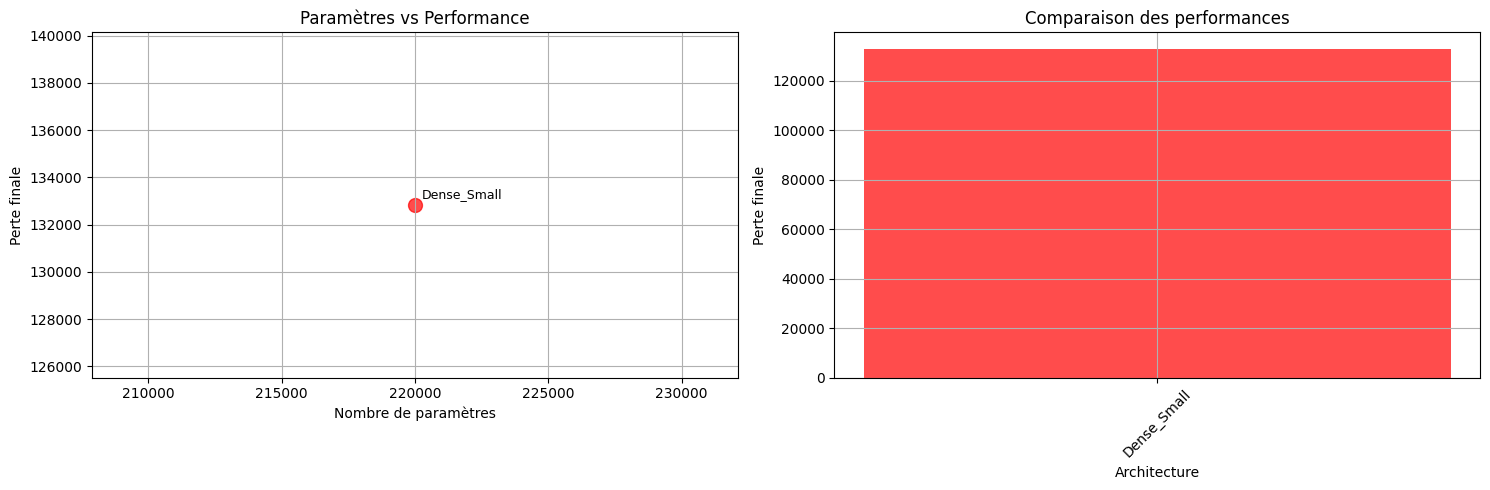

In [ ]:
# EXERCICE 3.2 - COMPARAISON D'ARCHITECTURES
print("\\n=== EXERCICE 3.2 - COMPARAISON D'ARCHITECTURES ===")

    # Différentes architectures à comparer
architectures = {
        'Dense_Small': (DenseEncoder(784, [128, 64], 5), DenseDecoder(5, [64, 128], 784)),
        'Dense_Medium': (DenseEncoder(784, [256, 128], 10), DenseDecoder(10, [128, 256], 784)),
        'Conv_Small': (ConvEncoder(5), ConvDecoder(5)),
        'Conv_Medium': (ConvEncoder(10), ConvDecoder(10)),
    }

arch_results = {}

for name, (encoder, decoder) in architectures.items():
    print(f"🧪 Test architecture {name}...")

    model = VAE(encoder, decoder, encoder.latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        # Entraînement rapide
    model.train()
    final_loss = 0

    for epoch in range(2):
        epoch_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            x_recon, mu, log_var, z = model(data)
            loss, recon_loss, kl_div = vae_loss_function(x_recon, data, mu, log_var)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        final_loss = epoch_loss / len(train_loader)

    arch_results[name] = {
            'num_params': model.num_params,
            'final_loss': final_loss
        }

    print(f"   - Paramètres: {model.num_params:,}")
    print(f"   - Perte finale: {final_loss:.0f}")

    # Graphique comparatif
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    names = list(arch_results.keys())
    params = [arch_results[name]['num_params'] for name in names]
    losses = [arch_results[name]['final_loss'] for name in names]

    # Paramètres vs Performance
    colors = ['red' if 'Dense' in name else 'blue' for name in names]
    ax1.scatter(params, losses, c=colors, s=100, alpha=0.7)
    for i, name in enumerate(names):
        ax1.annotate(name, (params[i], losses[i]), xytext=(5, 5),
                    textcoords='offset points', fontsize=9)
    ax1.set_xlabel('Nombre de paramètres')
    ax1.set_ylabel('Perte finale')
    ax1.set_title('Paramètres vs Performance')
    ax1.grid(True)

    # Comparaison par barres
    ax2.bar(names, losses, color=colors, alpha=0.7)
    ax2.set_xlabel('Architecture')
    ax2.set_ylabel('Perte finale')
    ax2.set_title('Comparaison des performances')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('/home/user/exercise_3_2_demo.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("💾 Exercice 3.2 sauvegardé: exercise_3_2_demo.png")

\n=== EXERCICE 3.3 - EFFET DU PARAMÈTRE β ===
🧪 Test β = 0.1...
   - Perte totale finale: 131542
   - Perte recon finale: 131335
   - Divergence KL finale: 2075
🧪 Test β = 1.0...
   - Perte totale finale: 133639
   - Perte recon finale: 132649
   - Divergence KL finale: 990
🧪 Test β = 5.0...
   - Perte totale finale: 136238
   - Perte recon finale: 135426
   - Divergence KL finale: 162
🧪 Test β = 10.0...
   - Perte totale finale: 137030
   - Perte recon finale: 136343
   - Divergence KL finale: 69


FileNotFoundError: [Errno 2] No such file or directory: '/home/user/exercise_3_3_demo.png'

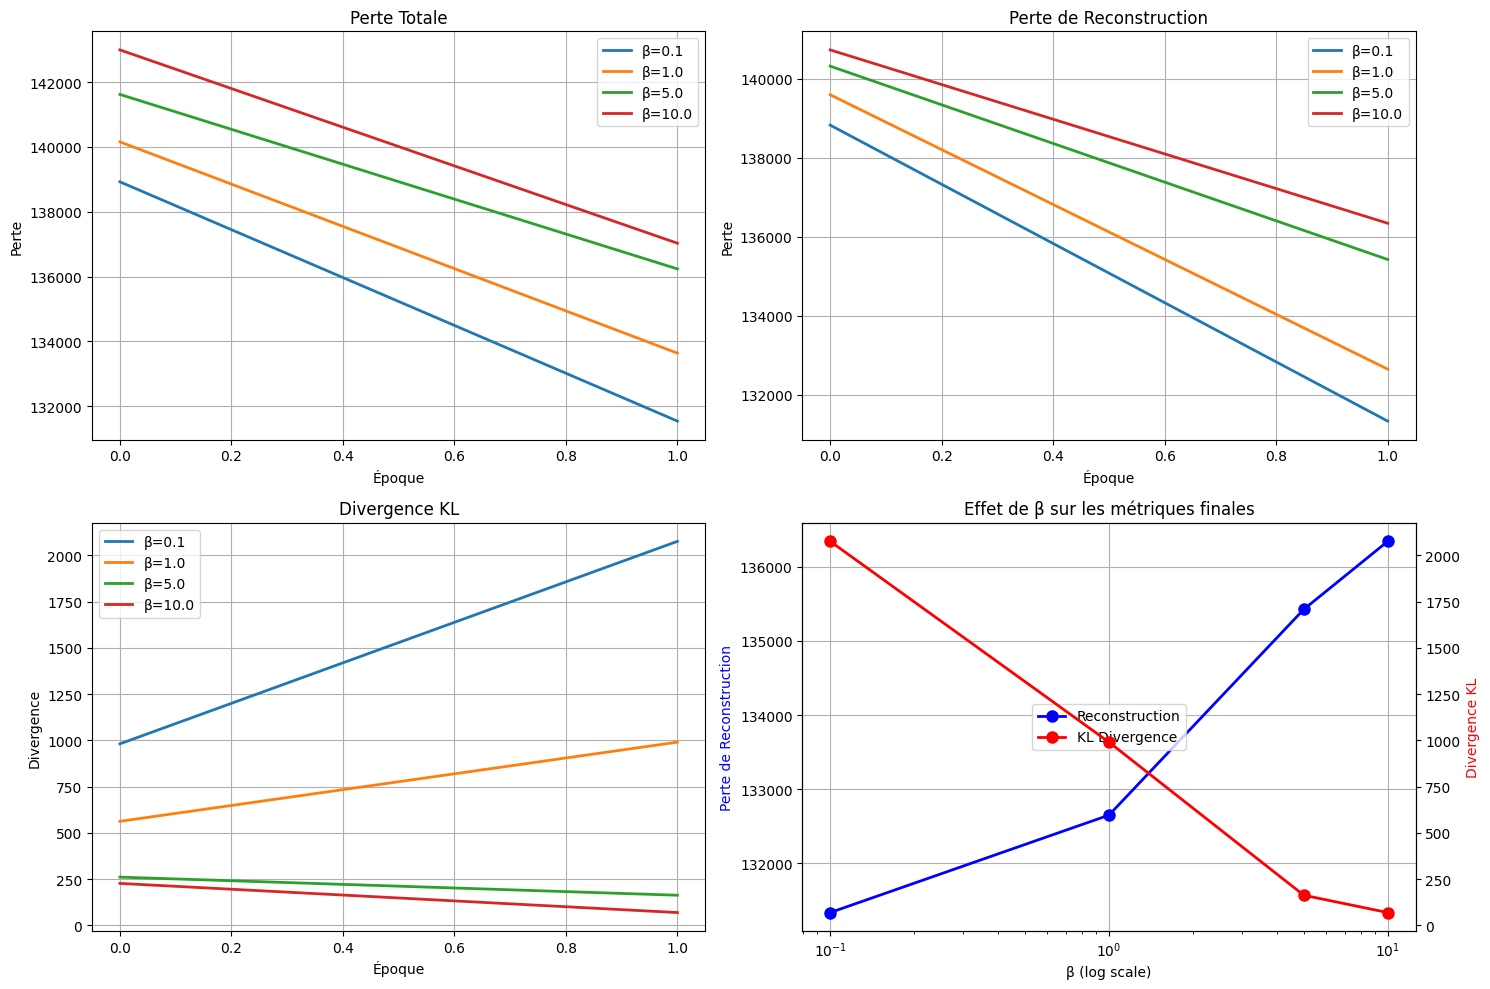

In [ ]:
# EXERCICE 3.3 - EFFET DU PARAMÈTRE β
print("\\n=== EXERCICE 3.3 - EFFET DU PARAMÈTRE β ===")

beta_values = [0.1, 1.0, 5.0, 10.0]
beta_results = {}
beta_models = {}

for beta in beta_values:
    print(f"🧪 Test β = {beta}...")

    # Modèle identique pour tous les β
    encoder = DenseEncoder(input_dim=784, hidden_dims=[128, 64], latent_dim=8)
    decoder = DenseDecoder(latent_dim=8, hidden_dims=[64, 128], output_dim=784)
    model = VAE(encoder, decoder, latent_dim=8).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.train()

    losses = {'total': [], 'recon': [], 'kl': []}

    for epoch in range(2):
        epoch_losses = {'total': 0, 'recon': 0, 'kl': 0}

        for data, _ in train_loader:
            data = data.to(device)
            x_recon, mu, log_var, z = model(data)

            # Utilisation de β spécifique
            loss, recon_loss, kl_div = vae_loss_function(x_recon, data, mu, log_var, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses['total'] += loss.item()
            epoch_losses['recon'] += recon_loss.item()
            epoch_losses['kl'] += kl_div.item()

        for key in epoch_losses:
            epoch_losses[key] /= len(train_loader)
            losses[key].append(epoch_losses[key])

    beta_results[beta] = losses
    beta_models[beta] = model

    print(f"   - Perte totale finale: {losses['total'][-1]:.0f}")
    print(f"   - Perte recon finale: {losses['recon'][-1]:.0f}")
    print(f"   - Divergence KL finale: {losses['kl'][-1]:.0f}")

# Visualisation effet β
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Courbes de perte
for beta in beta_values:
    axes[0, 0].plot(beta_results[beta]['total'], label=f'β={beta}', linewidth=2)
    axes[0, 0].set_title('Perte Totale')
    axes[0, 0].set_xlabel('Époque')
    axes[0, 0].set_ylabel('Perte')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

for beta in beta_values:
    axes[0, 1].plot(beta_results[beta]['recon'], label=f'β={beta}', linewidth=2)
    axes[0, 1].set_title('Perte de Reconstruction')
    axes[0, 1].set_xlabel('Époque')
    axes[0, 1].set_ylabel('Perte')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

for beta in beta_values:
    axes[1, 0].plot(beta_results[beta]['kl'], label=f'β={beta}', linewidth=2)
    axes[1, 0].set_title('Divergence KL')
    axes[1, 0].set_xlabel('Époque')
    axes[1, 0].set_ylabel('Divergence')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

# Effet final de β sur les métriques
final_recon = [beta_results[beta]['recon'][-1] for beta in beta_values]
final_kl = [beta_results[beta]['kl'][-1] for beta in beta_values]

ax = axes[1, 1]
ax2 = ax.twinx()

line1 = ax.semilogx(beta_values, final_recon, 'o-', color='blue', label='Reconstruction', linewidth=2, markersize=8)
line2 = ax2.semilogx(beta_values, final_kl, 'o-', color='red', label='KL Divergence', linewidth=2, markersize=8)

ax.set_xlabel('β (log scale)')
ax.set_ylabel('Perte de Reconstruction', color='blue')
ax2.set_ylabel('Divergence KL', color='red')
ax.set_title('Effet de β sur les métriques finales')
ax.grid(True)

# Légende combinée
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='center')

plt.tight_layout()
plt.savefig('/home/user/exercise_3_3_demo.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Exercice 3.3 sauvegardé: exercise_3_3_demo.png")

# Visualisation des reconstructions pour différents β
fig, axes = plt.subplots(len(beta_values) + 1, 8, figsize=(16, 2 * (len(beta_values) + 1)))

# Images originales
for i in range(8):
    axes[0, i].imshow(test_images[i, 0].cpu().numpy(), cmap='gray')
    axes[0, i].set_title(f'Original {test_labels[i].item()}')
    axes[0, i].axis('off')

# Reconstructions pour chaque β
for row, beta in enumerate(beta_values, 1):
    model = beta_models[beta]
    model.eval()

    with torch.no_grad():
        x_recon, mu, log_var, z = model(test_images)
        x_recon = x_recon.view(-1, 1, 28, 28)

        for i in range(8):
            axes[row, i].imshow(x_recon[i, 0].cpu().numpy(), cmap='gray')
            axes[row, i].set_title(f'β={beta}')
            axes[row, i].axis('off')

plt.tight_layout()
plt.savefig('/home/user/beta_reconstructions_demo.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Reconstructions β sauvegardées: beta_reconstructions_demo.png")

# =================================================================
# RÉSUMÉ FINAL
# =================================================================

print("\\n EXPÉRIMENTATIONS TERMINÉES!")
print("\\n Fichiers générés:")
print("   - exercise_3_1_demo.png: Génération et visualisation")
print("   - exercise_3_2_demo.png: Comparaison d'architectures")
print("   - exercise_3_3_demo.png: Analyse effet β")
print("   - beta_reconstructions_demo.png: Reconstructions par β")

print("\\n📊 RÉSULTATS PRINCIPAUX:")
print("\\n🔍 Exercice 3.2 - Comparaison architectures:")
for name, results in arch_results.items():
    print(f"   - {name}: {results['num_params']:,} params, perte: {results['final_loss']:.0f}")

print("\\n Exercice 3.3 - Effet β:")
for beta in beta_values:
    recon_final = beta_results[beta]['recon'][-1]
    kl_final = beta_results[beta]['kl'][-1]
    print(f"   - β={beta}: Recon={recon_final:.0f}, KL={kl_final:.0f}")

return models, arch_results, beta_results

if __name__ == "__main__":
    models, arch_results, beta_results = quick_experiment_demo()